### Pruebas en sucio

1-> Crear código que genere 8 fotos de coches
2-> Crear código que genere 8 fotos de patos
3-> A partir de esos dos códigos, definir uno que recoga como argumento el elemento del que obtener las imágenes y coordenadas

In [1]:
print('Hola')

Hola


In [7]:
# Import necessary libraries
import numpy as np          # Import NumPy for numerical operations and array handling
from PIL import Image      # Import PIL (Python Imaging Library) for image processing
import scipy.io as sio     # Import SciPy's IO module for reading .mat files
import matplotlib.pyplot as plt #Import Matplotlib 

# Define target size for image resizing (256x256 pixels)
obj_resize = (256, 256)

# Load duck images from the Willow Object Dataset
# These images will be used for feature matching
img1 = Image.open('./data/WillowObject/WILLOW-ObjectClass/Duck/060_0000.png')  # Load first duck image
img2 = Image.open('./data/WillowObject/WILLOW-ObjectClass/Duck/060_0010.png')  # Load second duck image

# Load keypoint annotations from corresponding .mat files
# 'pts_coord' contains the coordinates of manually annotated keypoints for each image
# Convert the MATLAB format to NumPy arrays for easier processing
kpts1 = np.array(sio.loadmat('./data/WillowObject/WILLOW-ObjectClass/Duck/060_0000.mat')['pts_coord'])  # Keypoints for first image
kpts2 = np.array(sio.loadmat('./data/WillowObject/WILLOW-ObjectClass/Duck/060_0010.mat')['pts_coord'])  # Keypoints for second image

# Scale keypoint coordinates to match the new image dimensions
# This ensures keypoints remain aligned when images are resized
kpts1[0] = kpts1[0] * obj_resize[0] / img1.size[0]  # Scale x-coordinates of first image keypoints
kpts1[1] = kpts1[1] * obj_resize[1] / img1.size[1]  # Scale y-coordinates of first image keypoints
kpts2[0] = kpts2[0] * obj_resize[0] / img2.size[0]  # Scale x-coordinates of second image keypoints
kpts2[1] = kpts2[1] * obj_resize[1] / img2.size[1]  # Scale y-coordinates of second image keypoints

# Resize both images to the target size (256x256)
# Using BILINEAR interpolation for smooth resizing
img1 = img1.resize(obj_resize, resample=Image.BILINEAR)  # Resize first image
img2 = img2.resize(obj_resize, resample=Image.BILINEAR)  # Resize second image

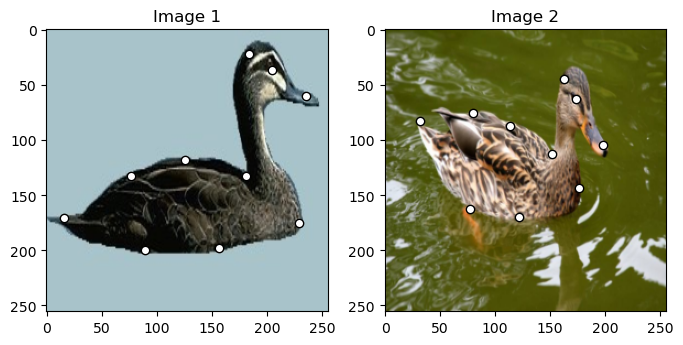

In [8]:
def plot_image_with_graph(img, kpt, A=None):
   """
   Function to visualize an image with keypoints and optional graph connections
   
   Parameters:
   - img: Input image to be displayed
   - kpt: Keypoints array with shape (2, N) where N is number of keypoints
   - A: Optional adjacency matrix for drawing connections between keypoints
   """
   # Display the input image
   plt.imshow(img)
   
   # Plot keypoints as white dots with black edges
   plt.scatter(kpt[0], kpt[1], c='w', edgecolors='k')
   
   # If an adjacency matrix is provided, draw connections between keypoints
   if A is not None:
       # Iterate through non-zero elements in adjacency matrix
       for idx in np.nonzero(A, as_tuple=False):
           # Draw black lines between connected keypoints
           # idx[0] is start point index, idx[1] is end point index
           plt.plot((kpt[0, idx[0]], kpt[0, idx[1]]), # x-coordinates of line
                   (kpt[1, idx[0]], kpt[1, idx[1]]),  # y-coordinates of line
                   'k-')                               # black solid line style

# Create a figure with specific size (8 inches width, 4 inches height)
plt.figure(figsize=(8, 4))

# Create first subplot for Image 1
plt.subplot(1, 2, 1)          # 1 row, 2 columns, first position
plt.title('Image 1')          # Set title for first subplot
plot_image_with_graph(img1, kpts1)  # Plot first image with its keypoints

# Create second subplot for Image 2
plt.subplot(1, 2, 2)          # 1 row, 2 columns, second position
plt.title('Image 2')          # Set title for second subplot
plot_image_with_graph(img2, kpts2)  # Plot second image with its keypoints

### EJERCICIO

In [41]:
# Import necessary libraries
import numpy as np          # Import NumPy for numerical operations and array handling
from PIL import Image      # Import PIL (Python Imaging Library) for image processing
import scipy.io as sio     # Import SciPy's IO module for reading .mat files
import matplotlib.pyplot as plt #Import Matplotlib 
import os 

# Define target size for image resizing (256x256 pixels)
obj_resize = (256, 256)

# Cargamos las imágenes
Car = './data/WillowObject/WILLOW-ObjectClass/Car'
pngs = []
mats = []
imgs = []
kpts_list = []
for img in os.listdir(Car):
    if img.endswith('.png'):
        pngs.append(img)
    elif img.endswith('.mat'):
        mats.append(img)

pngs.sort()
mats.sort()

for i in range(8):
    img = Image.open('./data/WillowObject/WILLOW-ObjectClass/Car' + '/' + pngs[i])
    kpts = np.array(sio.loadmat('./data/WillowObject/WILLOW-ObjectClass/Car' + '/' + mats[i])['pts_coord'])

    kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
    kpts[1] = kpts[1] * obj_resize[1] / img.size[1]

    img = img.resize(obj_resize, resample=Image.BILINEAR)

    kpts_list.append(kpts)
    imgs.append(img)



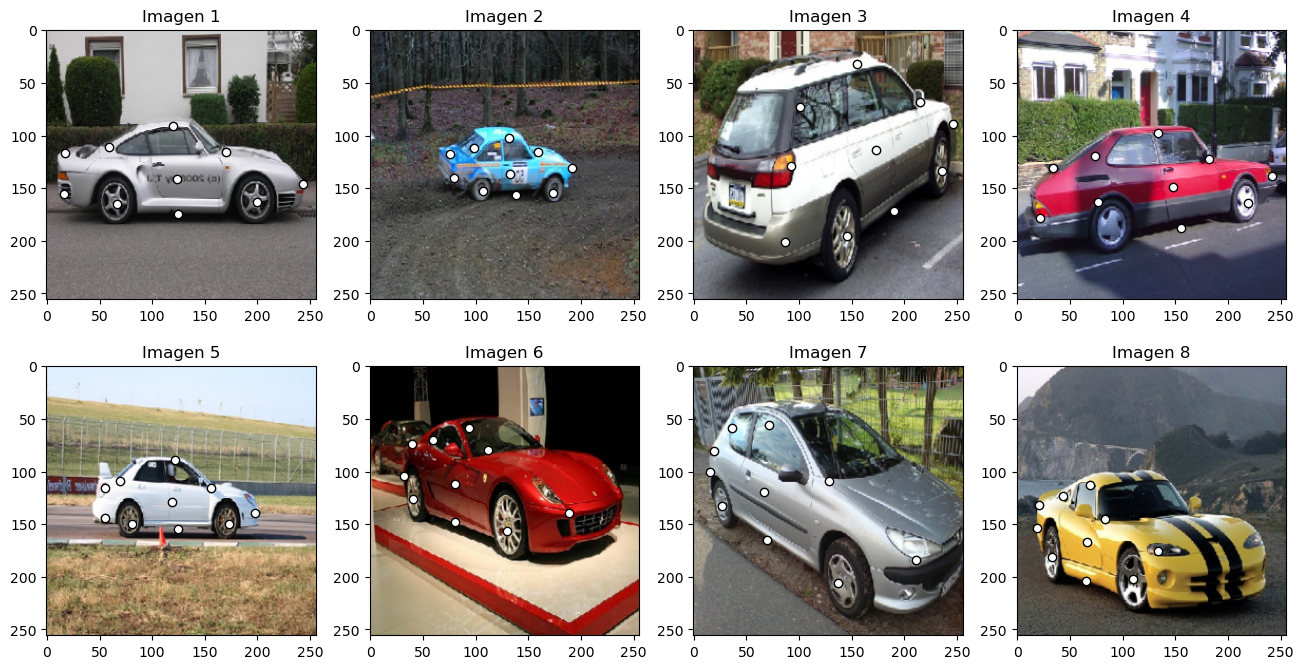

In [42]:
def plot_image_with_graph(img, kpt, A=None):
   """
   Function to visualize an image with keypoints and optional graph connections
   
   Parameters:
   - img: Input image to be displayed
   - kpt: Keypoints array with shape (2, N) where N is number of keypoints
   - A: Optional adjacency matrix for drawing connections between keypoints
   """
   # Display the input image
   plt.imshow(img)
   
   # Plot keypoints as white dots with black edges
   plt.scatter(kpt[0], kpt[1], c='w', edgecolors='k')
   
   # If an adjacency matrix is provided, draw connections between keypoints
   if A is not None:
       # Iterate through non-zero elements in adjacency matrix
       for idx in np.nonzero(A, as_tuple=False):
           # Draw black lines between connected keypoints
           # idx[0] is start point index, idx[1] is end point index
           plt.plot((kpt[0, idx[0]], kpt[0, idx[1]]), # x-coordinates of line
                   (kpt[1, idx[0]], kpt[1, idx[1]]),  # y-coordinates of line
                   'k-')                               # black solid line style

# Create a figure with specific size (8 inches width, 4 inches height)
plt.figure(figsize=(16, 8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.title(f'Imagen {i+1}')
    plot_image_with_graph(imgs[i],kpts_list[i])

### Ejercicio pero ahora con los patos

In [ ]:
# Import necessary libraries
import numpy as np          # Import NumPy for numerical operations and array handling
from PIL import Image      # Import PIL (Python Imaging Library) for image processing
import scipy.io as sio     # Import SciPy's IO module for reading .mat files
import matplotlib.pyplot as plt #Import Matplotlib 
import os 

# Define target size for image resizing (256x256 pixels)
obj_resize = (256, 256)

# Cargamos las imágenes
Duck = './data/WillowObject/WILLOW-ObjectClass/Duck'
pngs = []
mats = []
imgs = []
kpts_list = []
for img in os.listdir(Duck):
    if img.endswith('.png'):
        pngs.append(img)
    elif img.endswith('.mat'):
        mats.append(img)


for i in range(8):
    img = Image.open('./data/WillowObject/WILLOW-ObjectClass/Duck' + '/' + pngs[i])
    kpts = np.array(sio.loadmat('./data/WillowObject/WILLOW-ObjectClass/Duck' + '/' + mats[i])['pts_coord'])

    kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
    kpts[1] = kpts[1] * obj_resize[1] / img.size[1]

    img = img.resize(obj_resize, resample=Image.BILINEAR)

    kpts_list.append(kpts)
    imgs.append(img)



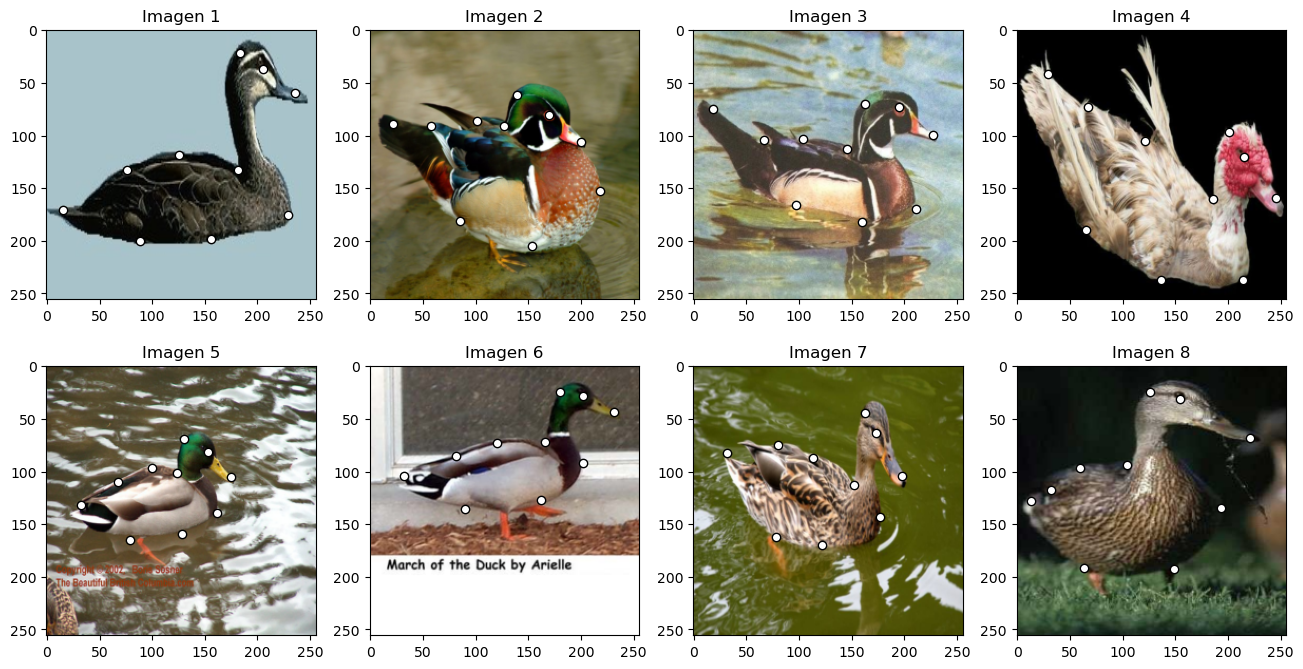

In [46]:
def plot_image_with_graph(img, kpt, A=None):
   """
   Function to visualize an image with keypoints and optional graph connections
   
   Parameters:
   - img: Input image to be displayed
   - kpt: Keypoints array with shape (2, N) where N is number of keypoints
   - A: Optional adjacency matrix for drawing connections between keypoints
   """
   # Display the input image
   plt.imshow(img)
   
   # Plot keypoints as white dots with black edges
   plt.scatter(kpt[0], kpt[1], c='w', edgecolors='k')
   
   # If an adjacency matrix is provided, draw connections between keypoints
   if A is not None:
       # Iterate through non-zero elements in adjacency matrix
       for idx in np.nonzero(A, as_tuple=False):
           # Draw black lines between connected keypoints
           # idx[0] is start point index, idx[1] is end point index
           plt.plot((kpt[0, idx[0]], kpt[0, idx[1]]), # x-coordinates of line
                   (kpt[1, idx[0]], kpt[1, idx[1]]),  # y-coordinates of line
                   'k-')                               # black solid line style

# Create a figure with specific size (8 inches width, 4 inches height)
plt.figure(figsize=(16, 8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.title(f'Imagen {i+1}')
    plot_image_with_graph(imgs[i],kpts_list[i])

## EJERCICIO FINAL

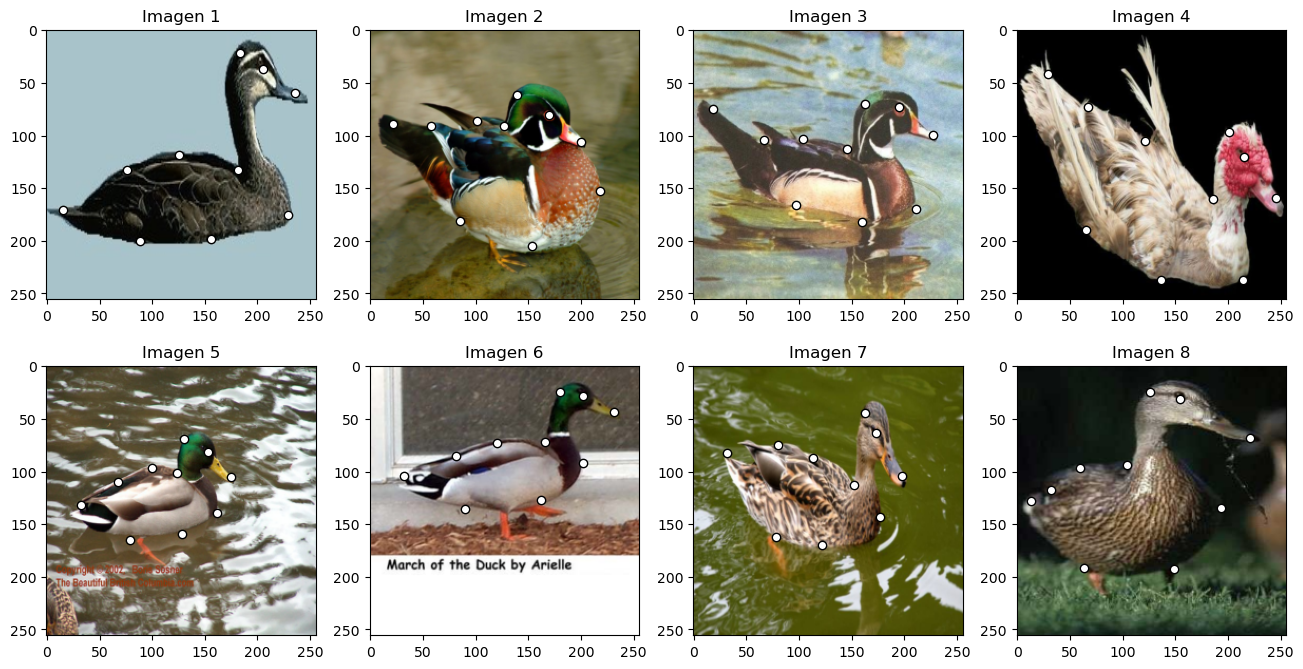

In [57]:
# Importamos las librerias
import numpy as np          # Import NumPy for numerical operations and array handling
from PIL import Image      # Import PIL (Python Imaging Library) for image processing
import scipy.io as sio     # Import SciPy's IO module for reading .mat files
import matplotlib.pyplot as plt #Import Matplotlib 
import os                   # Import os for iterating directories

def cargar_imagenes(categoría):

    # Definimos tamaño objeto
    obj_size = (256,256)

    category = './data/WillowObject/WILLOW-ObjectClass/' + category

    pngs = []
    mats = []
    # Recorremos directorio indicado
    # Guardamos los archivos png y mat en dos listas separadas (pero ordenadas)
    for img in os.listdir(category):
        if img.endswith('.png'):
            pngs.append(img)
        elif img.endswith('.mat'):
            mats.append(img)

    # Ya tenemos los pngs y mats guardados en listas
    for i in range(8):
        img = Image.open('./data/WillowObject/WILLOW-ObjectClass/' + category + '/' + pngs[i])
        kpts = np.array(sio.loadmat('./data/WillowObject/WILLOW-ObjectClass/' + category + '/' + mats[i])['pts_coord'])

        kpts[0] = kpts[0] * obj_resize[0] / img.size[0]
        kpts[1] = kpts[1] * obj_resize[1] / img.size[1]

        img = img.resize(obj_resize, resample=Image.BILINEAR)

        kpts_list.append(kpts)
        imgs.append(img)


def mostrar_imagenes(img, kpt, A=None):
   """
   Function to visualize an image with keypoints and optional graph connections
   
   Parameters:
   - img: Input image to be displayed
   - kpt: Keypoints array with shape (2, N) where N is number of keypoints
   - A: Optional adjacency matrix for drawing connections between keypoints
   """
   # Display the input image
   plt.imshow(img)
   
   # Plot keypoints as white dots with black edges
   plt.scatter(kpt[0], kpt[1], c='w', edgecolors='k')
   
   # If an adjacency matrix is provided, draw connections between keypoints
   if A is not None:
       # Iterate through non-zero elements in adjacency matrix
       for idx in np.nonzero(A, as_tuple=False):
           # Draw black lines between connected keypoints
           # idx[0] is start point index, idx[1] is end point index
           plt.plot((kpt[0, idx[0]], kpt[0, idx[1]]), # x-coordinates of line
                   (kpt[1, idx[0]], kpt[1, idx[1]]),  # y-coordinates of line
                   'k-')                               # black solid line style

# Create a figure with specific size (8 inches width, 4 inches height)
plt.figure(figsize=(16, 8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.title(f'Imagen {i+1}')
    mostrar_imagenes(imgs[i],kpts_list[i])

# EJERCICIO 1